# PA1 – Section 3: TD-based Control in Acrobot-v1


In [1]:

!pip install gymnasium --quiet

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from itertools import product
from scipy import stats
import warnings
import pickle
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
print('Gymnasium version:', gym.__version__)

Gymnasium version: 1.2.3


## 3.1  Discretisation (Binning)

Acrobot-v1 observation: `[cos θ₁, sin θ₁, cos θ₂, sin θ₂, θ̇₁, θ̇₂]`  
6-dimensional continuous space → discretise each dimension into **n_bins** equal bins.

**Number of states** = n_bins^6 = 10^6 = **1,000,000** for n_bins = 10.


In [2]:
def build_bins(env, divisions):
    # Clip angular velocities (dims 4,5) since Gymnasium lists them as ±inf
    low  = env.observation_space.low.copy()
    high = env.observation_space.high.copy()
    low  = np.clip(low,  -4 * np.pi, 4 * np.pi)
    high = np.clip(high, -4 * np.pi, 4 * np.pi)

    # Build one linspace per dimension
    bins = [np.linspace(low[i], high[i], divisions) for i in range(6)]
    return bins  # list of 6 arrays, one per observation dimension


def discretise(state, bins):
    # For each dimension, find which bin the value falls into
    return tuple(np.digitize(state[i], bins[i]) for i in range(6))

## 3.2  SARSA and Q-learning Implementations

**SARSA (on-policy TD):**
```
Q(S,A) ← Q(S,A) + α[R + γ Q(S',A') − Q(S,A)]
```

**Q-learning (off-policy TD):**
```
Q(S,A) ← Q(S,A) + α[R + γ max_a Q(S',a) − Q(S,A)]
```


## Q1 – Code for SARSA and Q-learning [3M]

SARSA

In [4]:
def run_sarsa(is_training=True, render=False,
              learning_rate=0.1,
              discount_factor=0.9,
              epsilon_start=1.0,
              epsilon_decay=0.002,
              epsilon_min=0.01,
              divisions=15,
              max_episodes=15000,
              seed=0):

    np.random.seed(seed)
    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    env.reset(seed=seed)
    bins = build_bins(env, divisions)

    if is_training:
        if seed == 0:
            # zero initialisation — deterministic baseline
            q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
        else:
            # random initialisation
            q = np.random.uniform(-0.01, 0.01, size=tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_sarsa.pkl', 'rb') as f:
            q = pickle.load(f)

    def choose_action(s):
        if is_training and np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q[s]))

    epsilon = epsilon_start
    best_reward = -999999
    rewards_per_episode = []
    episode = 0

    while episode < max_episodes:

        state, _ = env.reset()
        s = discretise(state, bins)
        action = choose_action(s)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:
            new_state, reward, terminated, truncated, _ = env.step(action)
            s_next = discretise(new_state, bins)
            action_next = choose_action(s_next)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * q[s_next][action_next] -
                    q[s][action]
                )

            s = s_next
            action = action_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_sarsa.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[SARSA] Episode: {episode}/{max_episodes}, ε: {epsilon:.2f}, '
                  f'Best: {best_reward:.1f}, Mean(100): {mean_reward:.1f}')

            mean_rewards = [np.mean(rewards_per_episode[max(0,t-100):t+1])
                            for t in range(episode)]

        if best_reward > env.spec.reward_threshold:
            print(f'[SARSA] Solved at episode {episode}!')
            break

        epsilon = max(epsilon - epsilon_decay, epsilon_min)
        episode += 1

    print(f'[SARSA] Training finished at episode {episode}.')
    env.close()
    return rewards_per_episode

Q-Learning

In [5]:
def run_qlearning(is_training=True, render=False,
                  learning_rate=0.1,
                  discount_factor=0.9,
                  epsilon_start=1.0,
                  epsilon_decay=0.002,
                  epsilon_min=0.01,
                  divisions=15,
                  max_episodes=15000,
                  seed=0):

    np.random.seed(seed)
    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    env.reset(seed=seed)
    bins = build_bins(env, divisions)

    if is_training:
        if seed == 0:
            # zero initialisation — deterministic baseline
            q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
        else:
            # random initialisation
            q = np.random.uniform(-0.01, 0.01,size=tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_qlearning.pkl', 'rb') as f:
            q = pickle.load(f)

    epsilon = epsilon_start
    best_reward = -999999
    rewards_per_episode = []
    episode = 0

    while episode < max_episodes:

        state, _ = env.reset()
        s = discretise(state, bins)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:
            if is_training and np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q[s])

            new_state, reward, terminated, truncated, _ = env.step(action)
            s_next = discretise(new_state, bins)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * np.max(q[s_next]) -
                    q[s][action]
                )

            s = s_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_qlearning.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[Q-learning] Episode: {episode}/{max_episodes}, ε: {epsilon:.2f}, '
                  f'Best: {best_reward:.1f}, Mean(100): {mean_reward:.1f}')

            mean_rewards = [np.mean(rewards_per_episode[max(0,t-100):t+1])
                            for t in range(episode)]
        if best_reward > env.spec.reward_threshold:
            print(f'[Q-learning] Solved at episode {episode}!')
            break

        epsilon = max(epsilon - epsilon_decay, epsilon_min)
        episode += 1

    print(f'[Q-learning] Training finished at episode {episode}.')
    env.close()
    return rewards_per_episode

## Q2a – Hyperparameter Tuning (top-3 configurations) [4M]

We sweep over α ∈ {0.1, 0.2} and ε ∈ {0.01, 0.1, 1.} which remain constant over training and later we train with an **exponential ε-decay to 0.01**(which is done later as constant ε is not sufficient for convergence to a good policy).



In [3]:
# 100 episode rolling mean
def rolling_mean(x, w=100):
    return [np.mean(x[max(0, t-w):t+1]) for t in range(len(x))]

In [14]:
# Constant Epsilons
learning_rates = [0.1, 0.2, 0.3]
epsilons = [0.01, 0.1, 1]

# store results here
sarsa_results = []
ql_results    = []

for i in range(len(learning_rates)):
    for j in range(len(epsilons)):

        print(f'\nTraining SARSA...[ α =' + str(learning_rates[i]) + ', ε =' + str(epsilons[j]) + ']')
        sarsa_rewards = run_sarsa(is_training=True, render=False,
                             learning_rate=learning_rates[i],
                             discount_factor=0.99,
                             epsilon_start=epsilons[j],
                             epsilon_decay=0,
                             epsilon_min=epsilons[j],
                             divisions=10,
                             max_episodes=5000,
                             seed = 0 )

        print('\nTraining Q-learning...[ α =' + str(learning_rates[i]) + ', ε =' + str(epsilons[j]) + ']')
        ql_rewards = run_qlearning(is_training=True, render=False,
                              learning_rate=learning_rates[i],
                              discount_factor=0.99,
                              epsilon_start=epsilons[j],
                              epsilon_decay=0,
                              epsilon_min=epsilons[j],
                              divisions=10,
                              max_episodes=5000,
                              seed = 0)

        # score = mean of last 100 episodes
        sarsa_score = np.mean(sarsa_rewards[-100:])
        ql_score    = np.mean(ql_rewards[-100:])

        # store (score, alpha, epsilon) for sorting later
        sarsa_results.append((sarsa_score, learning_rates[i], epsilons[j]))
        ql_results.append((ql_score,    learning_rates[i], epsilons[j]))


# sort by score descending
sarsa_results.sort(key=lambda x: -x[0])
ql_results.sort(key=lambda x:    -x[0])

print('TOP 3 SARSA CONFIGURATIONS')
for rank, (score, lr, eps) in enumerate(sarsa_results[:3], 1):
    print(f'#{rank}: α={lr:.1f}, ε={eps:.2f} → mean return={score:.1f}')


print('TOP 3 Q-LEARNING CONFIGURATIONS')
for rank, (score, lr, eps) in enumerate(ql_results[:3], 1):
    print(f'#{rank}: α={lr:.1f}, ε={eps:.2f} → mean return={score:.1f}')


Training SARSA...[ α =0.1, ε =0.01]
[SARSA] Episode: 100/5000, ε: 0.01, Best: -227.0, Mean(100): -483.9
[SARSA] Episode: 200/5000, ε: 0.01, Best: -153.0, Mean(100): -469.6
[SARSA] Episode: 300/5000, ε: 0.01, Best: -153.0, Mean(100): -472.2
[SARSA] Episode: 400/5000, ε: 0.01, Best: -153.0, Mean(100): -449.0
[SARSA] Episode: 500/5000, ε: 0.01, Best: -153.0, Mean(100): -451.0
[SARSA] Episode: 600/5000, ε: 0.01, Best: -153.0, Mean(100): -444.0
[SARSA] Episode: 700/5000, ε: 0.01, Best: -153.0, Mean(100): -422.1
[SARSA] Episode: 800/5000, ε: 0.01, Best: -153.0, Mean(100): -403.0
[SARSA] Episode: 900/5000, ε: 0.01, Best: -153.0, Mean(100): -388.7
[SARSA] Episode: 1000/5000, ε: 0.01, Best: -153.0, Mean(100): -397.6
[SARSA] Episode: 1100/5000, ε: 0.01, Best: -153.0, Mean(100): -409.7
[SARSA] Episode: 1200/5000, ε: 0.01, Best: -153.0, Mean(100): -372.7
[SARSA] Episode: 1300/5000, ε: 0.01, Best: -153.0, Mean(100): -353.7
[SARSA] Episode: 1400/5000, ε: 0.01, Best: -153.0, Mean(100): -346.1
[SARSA

In [15]:
best_lr_sar = 0.2
best_lr_ql  = 0.2


Training SARSA...
[SARSA] Episode: 100/8000, ε: 0.90, Best: -281.0, Mean(100): -496.3
[SARSA] Episode: 200/8000, ε: 0.80, Best: -224.0, Mean(100): -489.1
[SARSA] Episode: 300/8000, ε: 0.70, Best: -224.0, Mean(100): -489.8
[SARSA] Episode: 400/8000, ε: 0.60, Best: -224.0, Mean(100): -476.3
[SARSA] Episode: 500/8000, ε: 0.50, Best: -198.0, Mean(100): -451.3
[SARSA] Episode: 600/8000, ε: 0.40, Best: -187.0, Mean(100): -433.8
[SARSA] Episode: 700/8000, ε: 0.30, Best: -162.0, Mean(100): -400.4
[SARSA] Episode: 800/8000, ε: 0.20, Best: -159.0, Mean(100): -382.2
[SARSA] Episode: 900/8000, ε: 0.10, Best: -159.0, Mean(100): -370.5
[SARSA] Episode: 1000/8000, ε: 0.01, Best: -149.0, Mean(100): -362.0
[SARSA] Episode: 1100/8000, ε: 0.01, Best: -136.0, Mean(100): -351.0
[SARSA] Episode: 1200/8000, ε: 0.01, Best: -132.0, Mean(100): -324.5
[SARSA] Episode: 1300/8000, ε: 0.01, Best: -132.0, Mean(100): -340.5
[SARSA] Episode: 1400/8000, ε: 0.01, Best: -132.0, Mean(100): -334.3
[SARSA] Episode: 1500/80

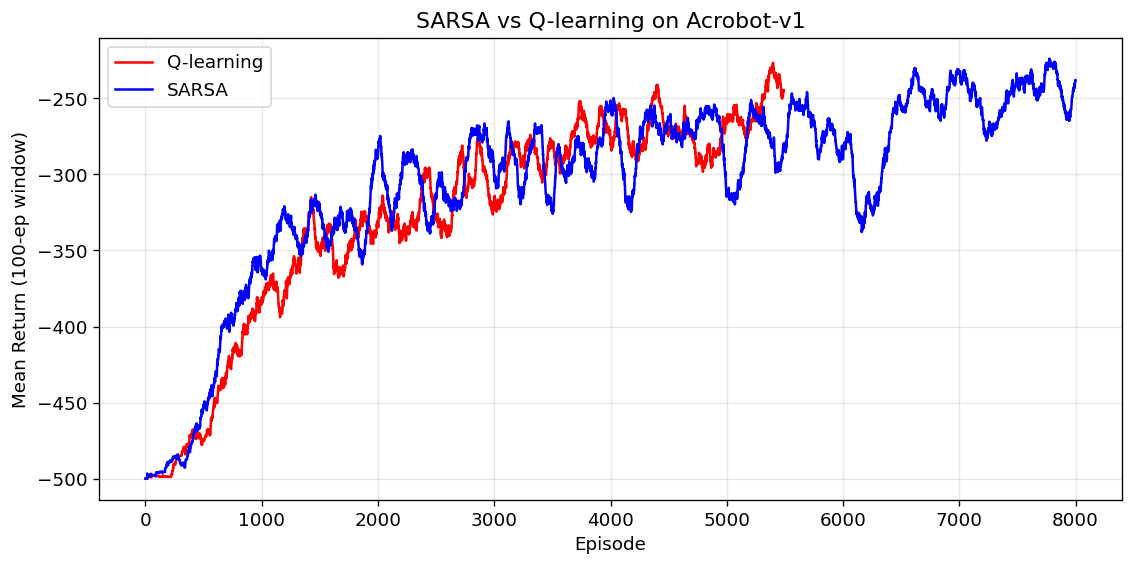

In [16]:
# Running both

print('\nTraining SARSA...')
sarsa_rewards = run_sarsa(is_training=True, render=False,
                           learning_rate=0.1,
                           discount_factor=0.99,
                           epsilon_start=1.0,
                           epsilon_decay=0.001,
                           epsilon_min=0.01,
                           divisions=10,
                           max_episodes=8000,
                           seed = 0)


print('\nTraining Q-learning...')
ql_rewards = run_qlearning(is_training=True, render=False,
                            learning_rate=0.1,
                            discount_factor=0.99,
                            epsilon_start=1.0,
                            epsilon_decay=0.001,
                            epsilon_min=0.01,
                            divisions=10,
                            max_episodes=8000,
                            seed = 0)


plt.figure(figsize=(11, 5))
plt.plot(rolling_mean(ql_rewards),    color='red',    label='Q-learning')
plt.plot(rolling_mean(sarsa_rewards), color='blue', label='SARSA')
plt.xlabel('Episode')
plt.ylabel('Mean Return (100-ep window)')
plt.title('SARSA vs Q-learning on Acrobot-v1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('acrobot_comparison.png')
plt.show()

## Q2b – Mean Performance ± CI over 10 Seeds [6M]

We use the **best hyperparameters** from tuning above and run 10 seeds.  
95% CI is computed as `mean ± 1.96 * std / sqrt(n_seeds)` (standard error of the mean).  


Seed 1/10...
[SARSA] Episode: 100/5000, ε: 0.95, Best: -372.0, Mean(100): -498.3
[SARSA] Episode: 200/5000, ε: 0.90, Best: -367.0, Mean(100): -497.9
[SARSA] Episode: 300/5000, ε: 0.85, Best: -344.0, Mean(100): -497.7
[SARSA] Episode: 400/5000, ε: 0.80, Best: -275.0, Mean(100): -487.1
[SARSA] Episode: 500/5000, ε: 0.75, Best: -275.0, Mean(100): -489.2
[SARSA] Episode: 600/5000, ε: 0.70, Best: -266.0, Mean(100): -477.3
[SARSA] Episode: 700/5000, ε: 0.65, Best: -219.0, Mean(100): -467.7
[SARSA] Episode: 800/5000, ε: 0.60, Best: -205.0, Mean(100): -440.6
[SARSA] Episode: 900/5000, ε: 0.55, Best: -205.0, Mean(100): -440.4
[SARSA] Episode: 1000/5000, ε: 0.50, Best: -155.0, Mean(100): -423.9
[SARSA] Episode: 1100/5000, ε: 0.45, Best: -155.0, Mean(100): -388.4
[SARSA] Episode: 1200/5000, ε: 0.40, Best: -150.0, Mean(100): -368.1
[SARSA] Episode: 1300/5000, ε: 0.35, Best: -150.0, Mean(100): -363.5
[SARSA] Episode: 1400/5000, ε: 0.30, Best: -150.0, Mean(100): -350.1
[SARSA] Episode: 1500/5000, ε:

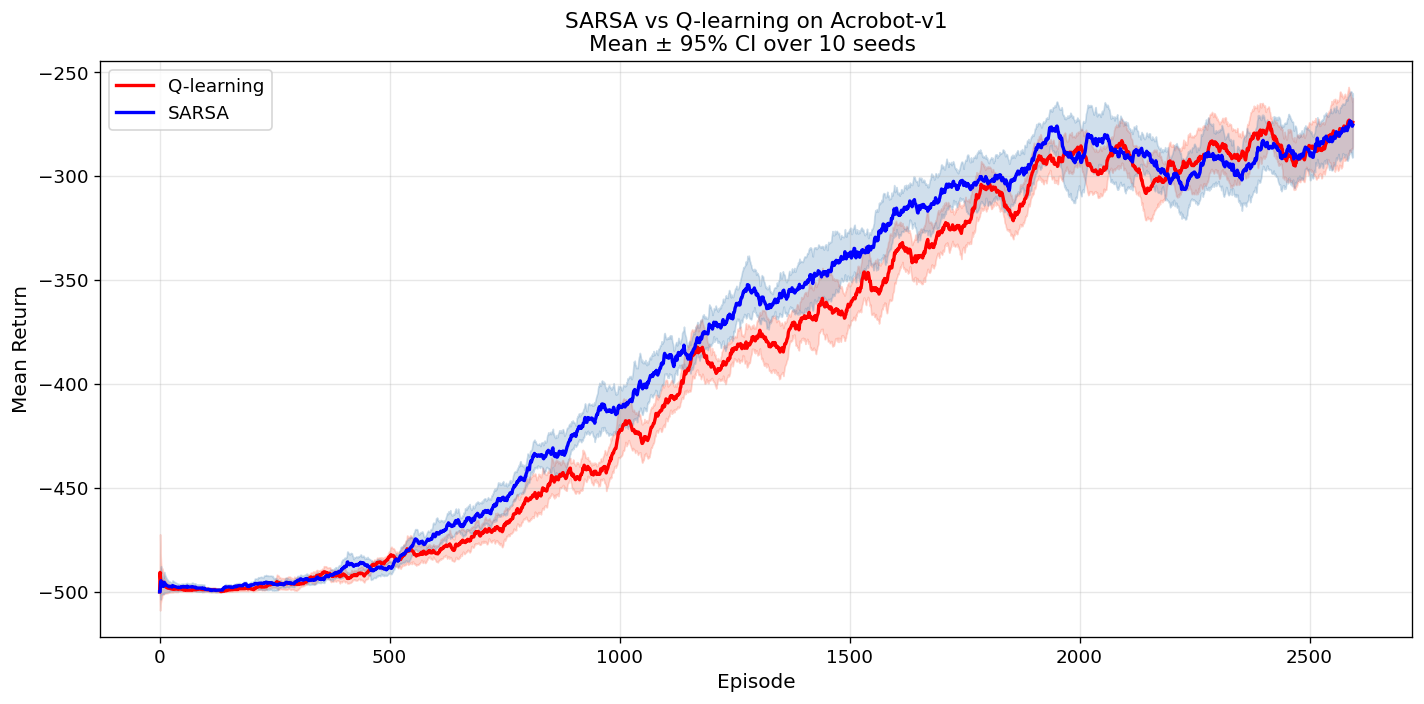

                            Q-learning        SARSA
Final mean return               -274.2       -275.5
Final CI width (±)                11.7         15.3
Best seed return                -254.7       -259.4
Worst seed return               -300.8       -303.2


In [17]:
N_SEEDS    = 10
SMOOTH_WIN = 50


ql_all_returns    = []
sarsa_all_returns = []

for seed in range(1, N_SEEDS + 1):   # seed=1 to 10 because seed=0 is zeros init and anything other than 0 is randomized
    print(f'Seed {seed}/{N_SEEDS}...')


    sarsa_rets = run_sarsa(is_training=True,
                           render=False,
                           learning_rate=best_lr_sar,
                           discount_factor=0.99,
                           epsilon_start=1.0,
                           epsilon_decay=0.0005,
                           epsilon_min=0.01,
                           divisions=10,
                           max_episodes=5000,
                           seed=seed)

    ql_rets = run_qlearning(is_training=True,
                            render=False,
                            learning_rate=best_lr_ql,
                            discount_factor=0.99,
                            epsilon_start=1.0,
                            epsilon_decay=0.0005,
                            epsilon_min=0.01,
                            divisions=10,
                            max_episodes=5000,
                            seed=seed)


 # rolling mean over 50 episodes
    sarsa_all_returns.append(rolling_mean(sarsa_rets, SMOOTH_WIN))
    ql_all_returns.append(rolling_mean(ql_rets,    SMOOTH_WIN))


# trimming all seeds to same length
min_len = min(min(len(r) for r in ql_all_returns),min(len(r) for r in sarsa_all_returns))

ql_matrix    = np.array([r[:min_len] for r in ql_all_returns])    # (10, min_len)
sarsa_matrix = np.array([r[:min_len] for r in sarsa_all_returns]) # (10, min_len)


fig, ax = plt.subplots(figsize=(12, 6))
episodes = np.arange(min_len)

# Q-learning
ql_mean = ql_matrix.mean(axis=0)
ql_ci   = 1.96 * stats.sem(ql_matrix, axis=0)
ax.plot(episodes, ql_mean,
        color='red', linewidth=2,
        label=f'Q-learning')
ax.fill_between(episodes,
                ql_mean - ql_ci,
                ql_mean + ql_ci,
                alpha=0.25, color='tomato')

# SARSA
sarsa_mean = sarsa_matrix.mean(axis=0)
sarsa_ci   = 1.96 * stats.sem(sarsa_matrix, axis=0)
ax.plot(episodes, sarsa_mean,
        color='blue', linewidth=2,
        label=f'SARSA')
ax.fill_between(episodes,
                sarsa_mean - sarsa_ci,
                sarsa_mean + sarsa_ci,
                alpha=0.25, color='steelblue')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean Return', fontsize=12)
ax.set_title(f'SARSA vs Q-learning on Acrobot-v1\n'
             f'Mean ± 95% CI over {N_SEEDS} seeds ',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q2b_mean_ci.png', bbox_inches='tight', dpi=150)
plt.show()


print(f'{"":25} {"Q-learning":>12} {"SARSA":>12}')
print(f'{"Final mean return":25} '
      f'{ql_mean[-1]:>12.1f} '
      f'{sarsa_mean[-1]:>12.1f}')
print(f'{"Final CI width (±)":25} '
      f'{ql_ci[-1]:>12.1f} '
      f'{sarsa_ci[-1]:>12.1f}')
print(f'{"Best seed return":25} '
      f'{ql_matrix[:,-100:].mean(axis=1).max():>12.1f} '
      f'{sarsa_matrix[:,-100:].mean(axis=1).max():>12.1f}')
print(f'{"Worst seed return":25} '
      f'{ql_matrix[:,-100:].mean(axis=1).min():>12.1f} '
      f'{sarsa_matrix[:,-100:].mean(axis=1).min():>12.1f}')


## Q3 – ε: 1→0.1 then Fixed; Online vs Final Policy [5M]

**Steps:**
- Decay ε linearly from 1.0 to 0.1 over `decay_episodes` episodes
- Fix ε = 0.1 thereafter
- Online performance = returns collected *during* training (includes exploration noise)
- Final policy performance = run agent *greedily* (ε=0) after training for N_EVAL episodes

In [18]:
# Training policy with ε= 1 to 0.1 (decaying exploration)
print('\nTraining SARSA...')
sarsa_rewards = run_sarsa(is_training=True, render=False,
                           learning_rate=best_lr_sar, # considering best learning rates
                           discount_factor=0.99,
                           epsilon_start=1.0,
                           epsilon_decay=0.0005,
                           epsilon_min=0.1,
                           divisions=10,
                           max_episodes=8000,
                           seed = 42)

print('Training Q-learning...')
ql_rewards = run_qlearning(is_training=True, render=False,
                            learning_rate=best_lr_ql, # considering best learning rate
                            discount_factor=0.99,
                            epsilon_start=1.0,
                            epsilon_decay=0.0005,
                            epsilon_min=0.1,
                            divisions=10,
                            max_episodes=8000,
                            seed = 42)



Training SARSA...
[SARSA] Episode: 100/8000, ε: 0.95, Best: -500.0, Mean(100): -500.0
[SARSA] Episode: 200/8000, ε: 0.90, Best: -298.0, Mean(100): -496.1
[SARSA] Episode: 300/8000, ε: 0.85, Best: -298.0, Mean(100): -497.1
[SARSA] Episode: 400/8000, ε: 0.80, Best: -194.0, Mean(100): -490.9
[SARSA] Episode: 500/8000, ε: 0.75, Best: -194.0, Mean(100): -485.7
[SARSA] Episode: 600/8000, ε: 0.70, Best: -194.0, Mean(100): -478.1
[SARSA] Episode: 700/8000, ε: 0.65, Best: -194.0, Mean(100): -458.3
[SARSA] Episode: 800/8000, ε: 0.60, Best: -194.0, Mean(100): -445.0
[SARSA] Episode: 900/8000, ε: 0.55, Best: -194.0, Mean(100): -447.5
[SARSA] Episode: 1000/8000, ε: 0.50, Best: -178.0, Mean(100): -427.4
[SARSA] Episode: 1100/8000, ε: 0.45, Best: -178.0, Mean(100): -403.5
[SARSA] Episode: 1200/8000, ε: 0.40, Best: -178.0, Mean(100): -402.2
[SARSA] Episode: 1300/8000, ε: 0.35, Best: -178.0, Mean(100): -389.1
[SARSA] Episode: 1400/8000, ε: 0.30, Best: -162.0, Mean(100): -354.1
[SARSA] Episode: 1500/80

Evaluating Q-learning greedy policy...
[Q-learning] Solved at episode 157!
[Q-learning] Training finished at episode 157.
Evaluating SARSA greedy policy...
[SARSA] Training finished at episode 500.


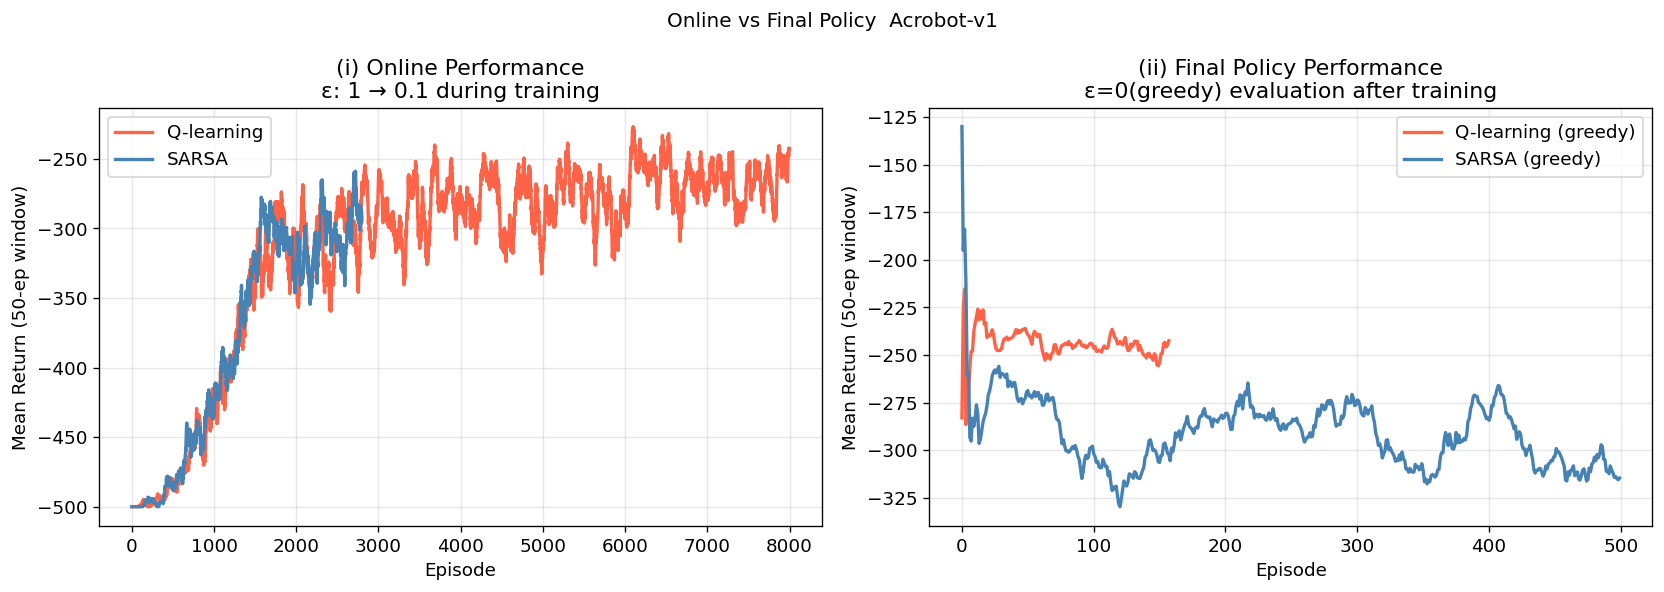

                            Q-learning        SARSA
Online mean (last 100)          -249.6       -288.4
Greedy mean (all 500)           -244.0       -293.6


In [19]:
# Evaluate final policy with ε=0 (no exploration)

print('Evaluating Q-learning greedy policy...')
ql_greedy_rewards = run_qlearning(is_training=False,   # loads Q-table from pickle file, no updates
                                   render=False,
                                   epsilon_start=0.0,  # always greedy
                                   epsilon_decay=0.0,
                                   epsilon_min=0.0,
                                   divisions=10,
                                   max_episodes=500,
                                   )

print('Evaluating SARSA greedy policy...')
sarsa_greedy_rewards = run_sarsa(is_training=False,    # loads Q-table from pickel file, no updates
                                  render=False,
                                  epsilon_start=0.0,   # always greedy
                                  epsilon_decay=0.0,
                                  epsilon_min=0.0,
                                  divisions=10,
                                  max_episodes=500,
                                  )


# Plot both comparisons side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Online performance
ax = axes[0]
ax.plot(rolling_mean(ql_rewards,    50), color='tomato',    label='Q-learning', linewidth=2)
ax.plot(rolling_mean(sarsa_rewards, 50), color='steelblue', label='SARSA',      linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Mean Return (50-ep window)')
ax.set_title('(i) Online Performance\nε: 1 → 0.1 during training')
ax.legend()
ax.grid(True, alpha=0.3)

# Final policy performance
ax2 = axes[1]
ax2.plot(rolling_mean(ql_greedy_rewards,    50), color='tomato',    label='Q-learning (greedy)', linewidth=2)
ax2.plot(rolling_mean(sarsa_greedy_rewards, 50), color='steelblue', label='SARSA (greedy)',      linewidth=2)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Mean Return (50-ep window)')
ax2.set_title('(ii) Final Policy Performance\nε=0(greedy) evaluation after training')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Online vs Final Policy  Acrobot-v1', fontsize=12)
plt.tight_layout()
plt.savefig('q3_online_vs_final.png', bbox_inches='tight')
plt.show()

print(f'{"":25} {"Q-learning":>12} {"SARSA":>12}')

print(f'{"Online mean (last 100)":25} '
      f'{np.mean(ql_rewards[-100:]):>12.1f} '
      f'{np.mean(sarsa_rewards[-100:]):>12.1f}')

print(f'{"Greedy mean (all 500)":25} '
      f'{np.mean(ql_greedy_rewards):>12.1f} '
      f'{np.mean(sarsa_greedy_rewards):>12.1f}')


## Q4 – Effect of Number of Bins [3M]

**Hypothesis:** More bins means finer state resolution which menas potentially better policy.  

We compare n_bins ∈ {5, 10, 15, 20} across 3 seeds (5 seeds would be better but is slow).


Training with 5 bins (states = 15,625)...
[SARSA] Episode: 100/5000, ε: 0.95, Best: -436.0, Mean(100): -499.4
[SARSA] Episode: 200/5000, ε: 0.90, Best: -426.0, Mean(100): -499.3
[SARSA] Episode: 300/5000, ε: 0.85, Best: -426.0, Mean(100): -499.8
[SARSA] Episode: 400/5000, ε: 0.80, Best: -342.0, Mean(100): -495.4
[SARSA] Episode: 500/5000, ε: 0.75, Best: -327.0, Mean(100): -495.0
[SARSA] Episode: 600/5000, ε: 0.70, Best: -284.0, Mean(100): -475.3
[SARSA] Episode: 700/5000, ε: 0.65, Best: -284.0, Mean(100): -489.8
[SARSA] Episode: 800/5000, ε: 0.60, Best: -227.0, Mean(100): -443.2
[SARSA] Episode: 900/5000, ε: 0.55, Best: -227.0, Mean(100): -468.6
[SARSA] Episode: 1000/5000, ε: 0.50, Best: -216.0, Mean(100): -468.9
[SARSA] Episode: 1100/5000, ε: 0.45, Best: -197.0, Mean(100): -424.8
[SARSA] Episode: 1200/5000, ε: 0.40, Best: -185.0, Mean(100): -375.4
[SARSA] Episode: 1300/5000, ε: 0.35, Best: -185.0, Mean(100): -437.1
[SARSA] Episode: 1400/5000, ε: 0.30, Best: -145.0, Mean(100): -362.5


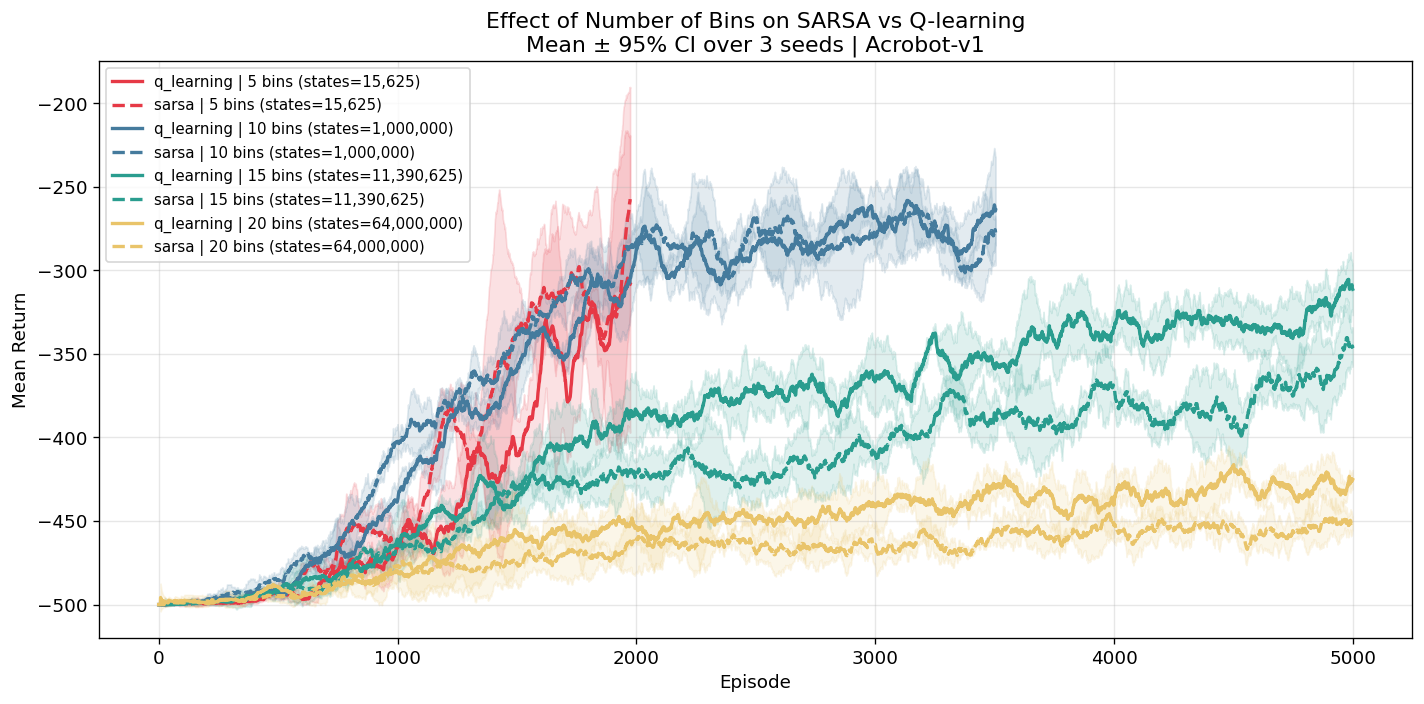

Bins           States     SARSA Final     Q-Learning Final
5              15,625          -308.1               -320.6
10          1,000,000          -287.0               -269.1
15         11,390,625          -352.7               -314.2
20         64,000,000          -450.2               -429.3


In [20]:
bins_list  = [5, 10, 15, 20]      # 10 = baseline
N_SEEDS    = 3
SMOOTH_WIN = 100
colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
bins_results = {}


for nb in bins_list:
    print(f'\nTraining with {nb} bins (states = {nb**6:,})...')
    sarsa_all_returns = []
    ql_all_returns    = []

    for seed in range(N_SEEDS):
        # SARSA
        sarsa_rets = run_sarsa(is_training=True,
                              render=False,
                              learning_rate=best_lr_sar,
                              discount_factor=0.99,
                              epsilon_start=1.0,
                              epsilon_decay=0.0005,
                              epsilon_min=0.01,
                              divisions=nb,
                              max_episodes=5000,
                              seed=seed
                              )
        # Q-Learning
        q_learning_rets = run_qlearning(is_training=True,
                                        render=False,
                                        learning_rate=best_lr_ql,
                                        discount_factor=0.99,
                                        epsilon_start=1.0,
                                        epsilon_decay=0.0005,
                                        epsilon_min=0.01,
                                        divisions=nb,
                                        max_episodes=5000,
                                        seed=seed
                                        )
        # smoothing
        sarsa_all_returns.append(rolling_mean(sarsa_rets, SMOOTH_WIN))
        ql_all_returns.append(rolling_mean(q_learning_rets, SMOOTH_WIN))

    # Trimming all seeds to same length
    min_len = min(min(len(r) for r in sarsa_all_returns), min(len(r) for r in ql_all_returns))

    sarsa_matrix = np.array([r[:min_len] for r in sarsa_all_returns])
    ql_matrix    = np.array([r[:min_len] for r in ql_all_returns])

    bins_results[nb] = {"sarsa": sarsa_matrix,"q_learning": ql_matrix}

    print(f'  SARSA last-100 mean = {np.mean(sarsa_matrix[:, -100:]):.1f}')
    print(f'  QL    last-100 mean = {np.mean(ql_matrix[:, -100:]):.1f}')

fig, ax = plt.subplots(figsize=(12, 6))

for nb, color in zip(bins_list, colors):

    for algo, linestyle in [("q_learning", "-"), ("sarsa", "--")]:

        matrix = bins_results[nb][algo]
        mean   = matrix.mean(axis=0)
        ci     = 1.96 * stats.sem(matrix, axis=0)
        episodes = np.arange(len(mean))

        ax.plot(episodes, mean, color=color, linestyle=linestyle, linewidth=2, label=f'{algo} | {nb} bins (states={nb**6:,})')
        ax.fill_between(episodes, mean - ci, mean + ci, alpha=0.15, color=color)

ax.set_xlabel('Episode')
ax.set_ylabel('Mean Return')
ax.set_title(f'Effect of Number of Bins on SARSA vs Q-learning\n' f'Mean ± 95% CI over {N_SEEDS} seeds | Acrobot-v1')

ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q4_bins_comparison.png', bbox_inches='tight')
plt.show()

print(f'{"Bins":<8} {"States":>12} {"SARSA Final":>15} {"Q-Learning Final":>20}')

for nb in bins_list:
    n_states = nb ** 6

    sarsa_final = np.mean(bins_results[nb]["sarsa"][:, -100:])
    ql_final    = np.mean(bins_results[nb]["q_learning"][:, -100:])

    print(f'{nb:<8} {n_states:>12,} {sarsa_final:>15.1f} {ql_final:>20.1f}')


## Q5 – Modified Reward Function Analysis (Theoretical) [12M]

$$r = \frac{\eta h}{2} + \text{sign}(-1 + \eta h)\left(\frac{2 - \eta h}{2}\right), \quad \eta > 0$$

where $h \in [-2, 2]$ is the tip height of the second link.

### Analysis of the reward function

The reward function simplifies to:
$$r = \begin{cases} \eta h - 1 & h < 1/\eta \\ 1 & h \geq 1/\eta \end{cases}$$

The original Acrobot reward is: $r = -1$ until $h \geq 1$, then episode terminates with $r=0$.


SARSA with shaped reward function

In [11]:
def run_sarsa_eta(is_training=True, render=False,
                  learning_rate=0.1,
                  discount_factor=0.99,
                  epsilon_start=1.0,
                  epsilon_decay=0.002,
                  epsilon_min=0.01,
                  divisions=10,
                  max_episodes=8000,
                  eta=0.5):

    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open(f'acrobot_sarsa_eta{eta}.pkl', 'rb') as f:
            q = pickle.load(f)

    def choose_action(s):
        if is_training and np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q[s]))

    epsilon = epsilon_start
    best_reward = -np.inf
    rewards_per_episode = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s = discretise(state, bins)
        action = choose_action(s)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:

            new_state, _, terminated, truncated, _ = env.step(action)

            # tip height: h
            ct1, st1, ct2, st2 = new_state[0], new_state[1], new_state[2], new_state[3]
            h = -ct1 - (ct1*ct2 - st1*st2)

            # piecewise reward
            if eta * h < 1:
                reward = eta * h - 1
            else:
                reward = 1

            s_next = discretise(new_state, bins)
            action_next = choose_action(s_next)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * q[s_next][action_next] -
                    q[s][action]
                )

            s      = s_next
            action = action_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open(f'acrobot_sarsa_eta{eta}.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[SARSA | η={eta}] Episode: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, Best: {best_reward:.2f}, '
                  f'Mean(100): {mean_reward:.2f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print(f'[SARSA | η={eta}] Training finished.')
    env.close()
    return rewards_per_episode

Q Learning with shaped reward

In [12]:
# Q Learning with updated reward
def run_qlearning_eta(is_training=True, render=False,
                      learning_rate=0.1,
                      discount_factor=0.99,
                      epsilon_start=1.0,
                      epsilon_decay=0.002,
                      epsilon_min=0.01,
                      divisions=10,
                      max_episodes=8000,
                      eta=0.5):

    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open(f'acrobot_qlearning_eta{eta}.pkl', 'rb') as f:
            q = pickle.load(f)

    epsilon = epsilon_start
    best_reward = -np.inf
    rewards_per_episode = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s = discretise(state, bins)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:

            if is_training and np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q[s]))

            new_state, _, terminated, truncated, _ = env.step(action)

            ct1, st1, ct2, st2 = new_state[0], new_state[1], new_state[2], new_state[3]
            h = -ct1 - (ct1*ct2 - st1*st2)

            # piecewise reward

            if eta * h < 1:
                reward = eta * h - 1
            else:
                reward = 1

            s_next = discretise(new_state, bins)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * np.max(q[s_next]) -
                    q[s][action]
                )

            s = s_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open(f'acrobot_qlearning_eta{eta}.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[Q-learning | η={eta}] Episode: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, Best: {best_reward:.2f}, '
                  f'Mean(100): {mean_reward:.2f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print(f'[Q-learning | η={eta}] Training finished.')
    env.close()
    return rewards_per_episode

## Bonus (Q6) – Empirical Support for Q5 Arguments

We run Q-learning with the **modified reward** for η ∈ {0.5, 1, 2, 5} and compare learning curves.
Since Gymnasium's Acrobot-v1 terminates at h≥1 (hardcoded), the episode structure is preserved,
but we change the reward function.




Training Q-learning | η=0.5...
[Q-learning | η=0.5] Episode: 100/5000, ε: 0.950, Best: -779.59, Mean(100): -922.36
[Q-learning | η=0.5] Episode: 200/5000, ε: 0.900, Best: -686.99, Mean(100): -887.81
[Q-learning | η=0.5] Episode: 300/5000, ε: 0.850, Best: -489.78, Mean(100): -862.13
[Q-learning | η=0.5] Episode: 400/5000, ε: 0.800, Best: -489.78, Mean(100): -847.91
[Q-learning | η=0.5] Episode: 500/5000, ε: 0.750, Best: -452.97, Mean(100): -829.15
[Q-learning | η=0.5] Episode: 600/5000, ε: 0.700, Best: -452.97, Mean(100): -786.31
[Q-learning | η=0.5] Episode: 700/5000, ε: 0.650, Best: -338.86, Mean(100): -749.73
[Q-learning | η=0.5] Episode: 800/5000, ε: 0.600, Best: -328.07, Mean(100): -729.33
[Q-learning | η=0.5] Episode: 900/5000, ε: 0.550, Best: -266.75, Mean(100): -695.22
[Q-learning | η=0.5] Episode: 1000/5000, ε: 0.500, Best: -266.75, Mean(100): -670.20
[Q-learning | η=0.5] Episode: 1100/5000, ε: 0.450, Best: -266.75, Mean(100): -651.57
[Q-learning | η=0.5] Episode: 1200/5000, ε

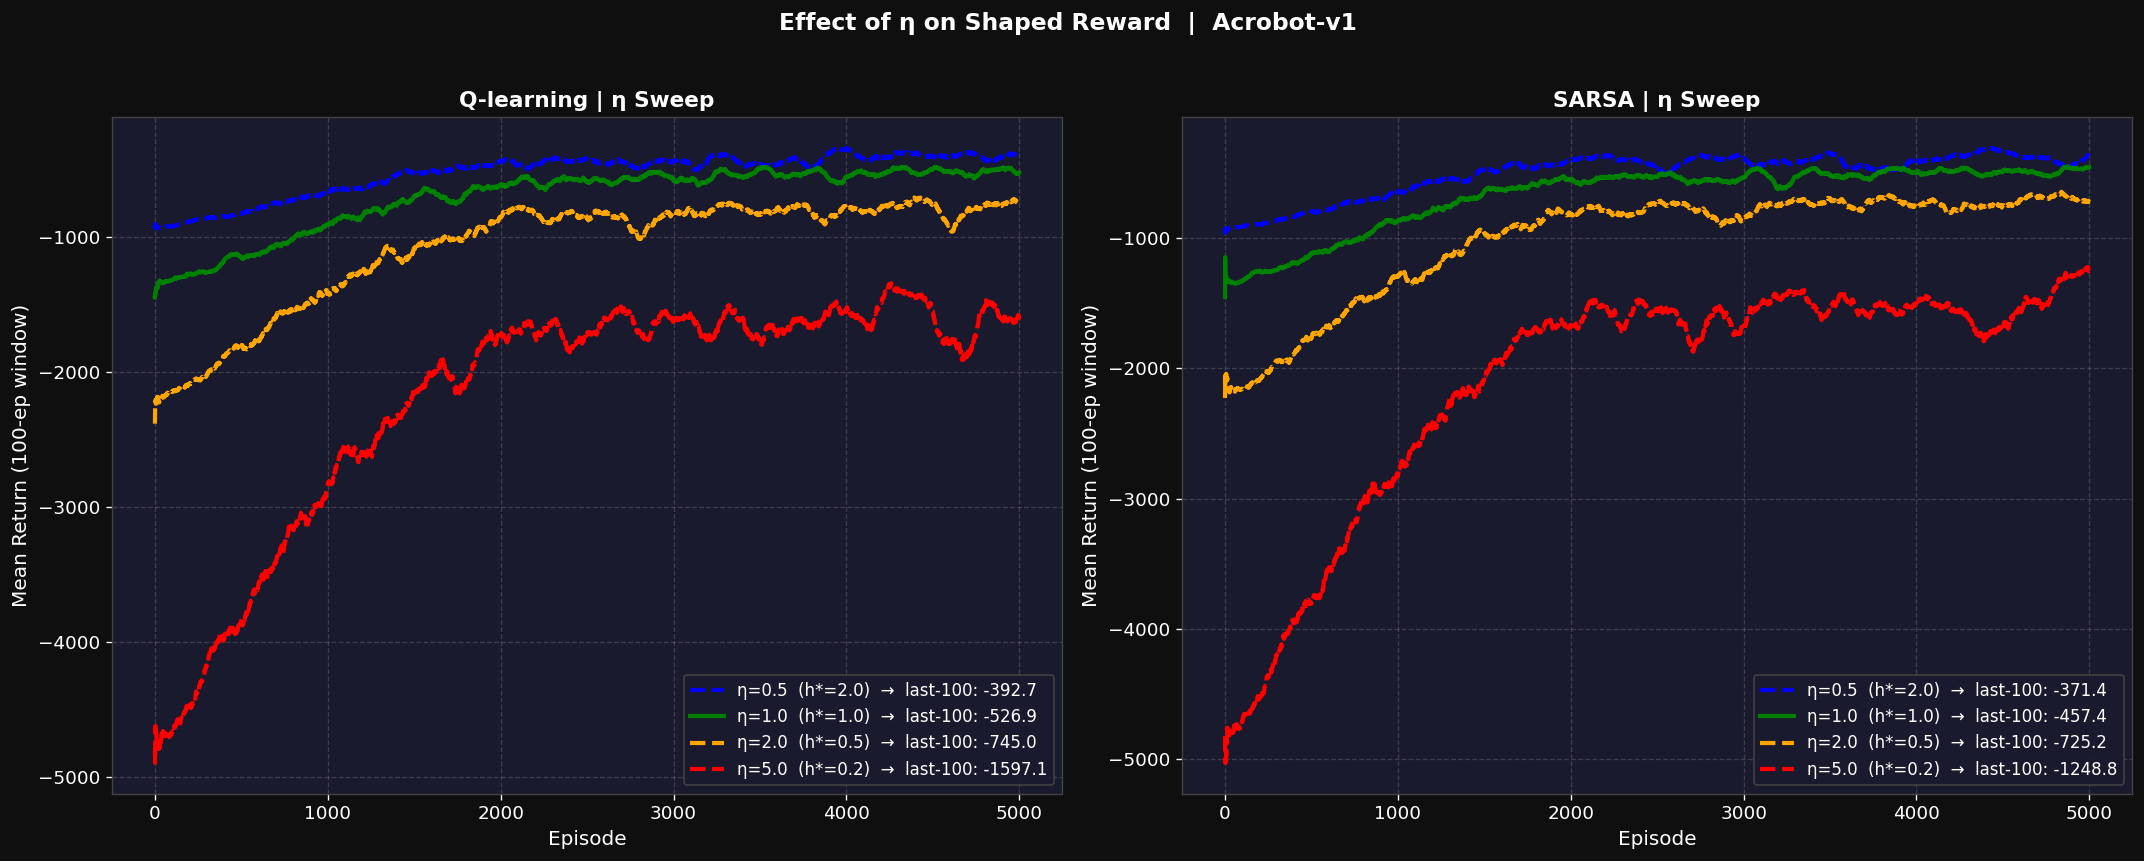

η         h* (sat.)     QL last-100  SARSA last-100
0.5            2.00          -392.7          -371.4
1.0            1.00          -526.9          -457.4
2.0            0.50          -745.0          -725.2
5.0            0.20         -1597.1         -1248.8


In [14]:
# Eta sweep

ETAS       = [0.5, 1.0, 2.0, 5.0]
SMOOTH_WIN = 100

ql_eta_rewards    = {}
sarsa_eta_rewards = {}

for eta in ETAS:
    print(f'\nTraining Q-learning | η={eta}...')
    ql_eta_rewards[eta] = run_qlearning_eta(is_training=True, render=False,
                                             learning_rate=0.1,
                                             discount_factor=0.99,
                                             epsilon_start=1.0,
                                             epsilon_decay=0.0005,
                                             epsilon_min=0.01,
                                             divisions=10,
                                             max_episodes=5000,
                                             eta=eta)

    print(f'\nTraining SARSA | η={eta}...')
    sarsa_eta_rewards[eta] = run_sarsa_eta(is_training=True, render=False,
                                            learning_rate=0.1,
                                            discount_factor=0.99,
                                            epsilon_start=1.0,
                                            epsilon_decay=0.0005,
                                            epsilon_min=0.01,
                                            divisions=10,
                                            max_episodes=5000,
                                            eta=eta)



eta_colors = {
    0.5: 'blue',
    1.0: 'green',
    2.0: 'orange',
    5.0: 'red',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.grid(True, alpha=0.15, color='white', linestyle='--')

# Q-learning
ax = axes[0]
for eta in ETAS:
    smoothed = rolling_mean(ql_eta_rewards[eta], SMOOTH_WIN)
    ax.plot(smoothed,
            color=eta_colors[eta],
            linewidth=2.5,
            linestyle='-' if eta == 1.0 else '--',
            label=f'η={eta}  (h*={1/eta:.1f})  →  last-100: {np.mean(ql_eta_rewards[eta][-100:]):.1f}')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean Return (100-ep window)', fontsize=12)
ax.set_title('Q-learning | η Sweep', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white',
          edgecolor='#444444', framealpha=0.9)

# SARSA
ax2 = axes[1]
for eta in ETAS:
    smoothed = rolling_mean(sarsa_eta_rewards[eta], SMOOTH_WIN)
    ax2.plot(smoothed,
             color=eta_colors[eta],
             linewidth=2.5,
             linestyle='-' if eta == 1.0 else '--',
             label=f'η={eta}  (h*={1/eta:.1f})  →  last-100: {np.mean(sarsa_eta_rewards[eta][-100:]):.1f}')

ax2.set_xlabel('Episode', fontsize=12)
ax2.set_ylabel('Mean Return (100-ep window)', fontsize=12)
ax2.set_title('SARSA | η Sweep', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, facecolor='#1a1a2e', labelcolor='white',
           edgecolor='#444444', framealpha=0.9)

fig.suptitle('Effect of η on Shaped Reward  |  Acrobot-v1 ',
             fontsize=14, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('eta_sweep.png', bbox_inches='tight', dpi=150, facecolor='#0f0f0f')
plt.show()




print(f'{"η":<8} {"h* (sat.)":>10} {"QL last-100":>15} {"SARSA last-100":>15}')

for eta in ETAS:
    ql_score    = np.mean(ql_eta_rewards[eta][-100:])
    sarsa_score = np.mean(sarsa_eta_rewards[eta][-100:])
    print(f'{eta:<8.1f} {1/eta:>10.2f} {ql_score:>15.1f} {sarsa_score:>15.1f}')


## Physics-Based Reward Function

Instead of the standard sparse reward (`r = -1` per step), we design a reward using domain
knowledge about the Acrobot's mechanics:
```python
reward = 0.4  * height_of_tip       # primary signal — higher tip = better
       + 0.02 * resonance_condition  # reward torque in-phase with link 1 motion
       + 0.01 * alignment            # reward link alignment near neutral state
       - 0.04 * w2_penalty           # penalise link 2 rotating in wrong direction
```

**Height** (`-cos θ1 - cos(θ1+θ2)`) is the dominant term — directly proportional to progress toward the goal.

**Resonance** (`(action-1) × ω1`) rewards applying torque in the same direction as link 1's
velocity, analogous to pumping a swing — this efficiently transfers energy into the system
(inspired by Spong 1995).

**Alignment** (`cos θ2 × max(0, -cos θ1)`) encourages both links to move together as a single
pendulum when near the neutral hanging position, maximising inertia for the upswing.

**Penalty** (`max(0, -ω2)`) only penalises link 2 when it rotates in the direction that
opposes the upswing — an unconditional penalty would also hurt beneficial momentum.


SARSA with custom reward

In [15]:
#SARSA
def run_sarsa_upd(is_training=True, render=False,
                  learning_rate=0.1,
                  discount_factor=0.9,
                  epsilon_start=1.0,
                  epsilon_decay=0.002,
                  epsilon_min=0.01,
                  divisions=15,
                  max_episodes=8000):

    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_sarsa_upd.pkl', 'rb') as f:
            q = pickle.load(f)

    def choose_action(s):
        if is_training and np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q[s]))

    epsilon = epsilon_start
    best_reward = -np.inf
    rewards_per_episode = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s = discretise(state, bins)
        action = choose_action(s)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:

            new_state, _, terminated, truncated, _ = env.step(action)


            [ct1, st1, ct2, st2, w1, w2] = new_state


            height_of_tip = -ct1 - ct1*ct2 + st1*st2

            # Resonance: torque direction in-phase with link 1 velocity
            # action-1 gives {-1, 0, +1} as torque direction proxy
            resonance_condition = (action - 1) * w1

            # Alignment: links aligned when link 1 is in upper half
            # encourages simple-pendulum behaviour near neutral state
            alignment = ct2 * max(0, -ct1)

            # Penalty on w2 only when it opposes desired motion
            # (unconditional penalty hurts momentum build-up)
            w2_penalty = max(0, -w2)

            # Computing custom reward
            reward = (0.4  * height_of_tip
                    + 0.02 * resonance_condition
                    + 0.01 * alignment
                    - 0.04 * w2_penalty)

            s_next = discretise(new_state, bins)
            action_next = choose_action(s_next)


            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * q[s_next][action_next] -
                    q[s][action]
                )

            s      = s_next
            action = action_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_sarsa_upd.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 50 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[SARSA] Episode: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Best: {best_reward:.3f}, '
                  f'Mean(100): {mean_reward:.2f}')

            mean_rewards = [
                np.mean(rewards_per_episode[max(0, t-100):t+1])
                for t in range(len(rewards_per_episode))
            ]

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print('SARSA Training finished.')
    env.close()
    return rewards_per_episode

Q Learning with custom reward

In [16]:
# Q Learning
def run_qlearning_upd(is_training=True, render=False,
                      learning_rate=0.1,
                      discount_factor=0.9,
                      epsilon_start=1.0,
                      epsilon_decay=0.002,
                      epsilon_min=0.01,
                      divisions=15,
                      max_episodes=8000):

    env = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_qlearning_upd.pkl', 'rb') as f:
            q = pickle.load(f)

    epsilon = epsilon_start
    best_reward = -np.inf
    rewards_per_episode = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s = discretise(state, bins)
        terminated = False
        truncated  = False
        ep_reward  = 0

        while not terminated and not truncated:

            if is_training and np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q[s]))

            new_state, _, terminated, truncated, _ = env.step(action)


            [ct1, st1, ct2, st2, w1, w2] = new_state

            height_of_tip = -ct1 - ct1*ct2 + st1*st2

            # Resonance: torque direction in-phase with link 1 velocity
            # action-1 gives {-1, 0, +1} as torque direction proxy
            resonance_condition = (action - 1) * w1

            # Alignment: links aligned when link 1 is in upper half
            # encourages simple-pendulum behaviour near neutral state
            alignment = ct2 * max(0, -ct1)

            # Penalty on w2 only when it opposes desired motion
            # (unconditional penalty hurts momentum build-up)
            w2_penalty = max(0, -w2)

            # Computing custom reward
            reward = (0.4  * height_of_tip
                    + 0.02 * resonance_condition
                    + 0.01 * alignment
                    - 0.04 * w2_penalty)

            s_next = discretise(new_state, bins)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * np.max(q[s_next]) -
                    q[s][action]
                )

            s = s_next
            ep_reward += reward

        rewards_per_episode.append(ep_reward)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_qlearning_upd.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 50 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            print(f'[Q-learning] Episode: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Best: {best_reward:.3f}, '
                  f'Mean(100): {mean_reward:.2f}')

            mean_rewards = [
                np.mean(rewards_per_episode[max(0, t-100):t+1])
                for t in range(len(rewards_per_episode))
            ]

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print('Q-learning Training finished.')
    env.close()
    return rewards_per_episode


Training SARSA...
[SARSA] Episode: 50/8000, ε: 0.975, Best: -270.389, Mean(100): -355.30
[SARSA] Episode: 100/8000, ε: 0.950, Best: -270.389, Mean(100): -352.23
[SARSA] Episode: 150/8000, ε: 0.925, Best: -265.090, Mean(100): -342.61
[SARSA] Episode: 200/8000, ε: 0.900, Best: -260.569, Mean(100): -336.53
[SARSA] Episode: 250/8000, ε: 0.875, Best: -192.972, Mean(100): -332.01
[SARSA] Episode: 300/8000, ε: 0.850, Best: -192.972, Mean(100): -323.86
[SARSA] Episode: 350/8000, ε: 0.825, Best: -169.033, Mean(100): -314.85
[SARSA] Episode: 400/8000, ε: 0.800, Best: -169.033, Mean(100): -312.73
[SARSA] Episode: 450/8000, ε: 0.775, Best: -169.033, Mean(100): -311.30
[SARSA] Episode: 500/8000, ε: 0.750, Best: -164.053, Mean(100): -291.05
[SARSA] Episode: 550/8000, ε: 0.725, Best: -164.053, Mean(100): -282.88
[SARSA] Episode: 600/8000, ε: 0.700, Best: -164.053, Mean(100): -287.75
[SARSA] Episode: 650/8000, ε: 0.675, Best: -156.431, Mean(100): -277.28
[SARSA] Episode: 700/8000, ε: 0.650, Best: -15

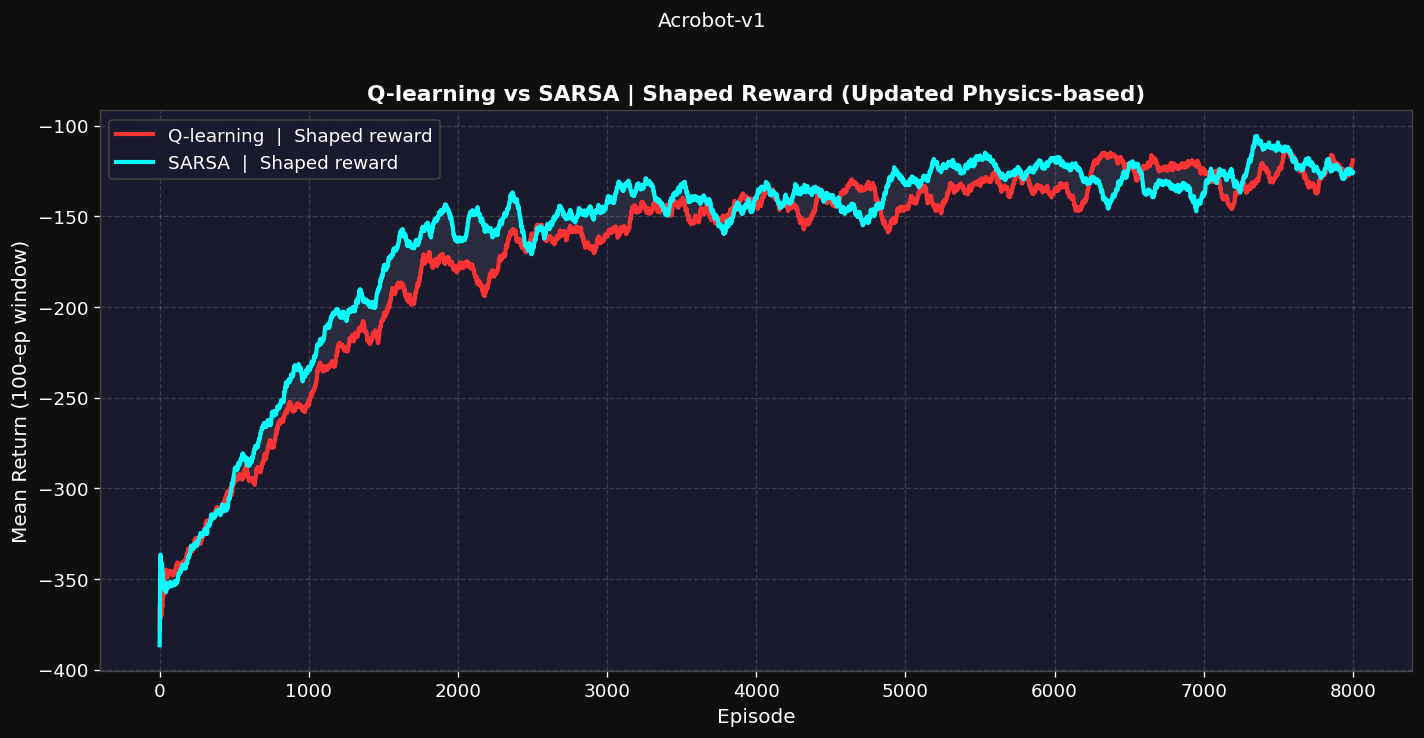

                       Q-learning        SARSA
Last 100 mean              -119.0       -125.9
Best episode                -60.0        -51.9


In [17]:
print('\nTraining SARSA...')
sarsa_upd_rewards = run_sarsa_upd(is_training=True, render=False,
                                   learning_rate=0.1,
                                   discount_factor=0.99,
                                   epsilon_start=1.0,
                                   epsilon_decay=0.0005,
                                   epsilon_min=0.01,
                                   divisions=10,
                                   max_episodes=8000)


print('Training Q-learning...')
ql_upd_rewards = run_qlearning_upd(is_training=True, render=False,
                                    learning_rate=0.1,
                                    discount_factor=0.99,
                                    epsilon_start=1.0,
                                    epsilon_decay=0.0005,
                                    epsilon_min=0.01,
                                    divisions=10,
                                    max_episodes=8000)



SMOOTH_WIN = 100

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')

ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444444')
ax.grid(True, alpha=0.15, color='white', linestyle='--')

ql_upd_smooth   = rolling_mean(ql_upd_rewards,   SMOOTH_WIN)
sarsa_upd_smooth = rolling_mean(sarsa_upd_rewards, SMOOTH_WIN)

ax.plot(ql_upd_smooth,
        color='#FF3333', linewidth=2.5, linestyle='-',
        label='Q-learning  |  Shaped reward')
ax.plot(sarsa_upd_smooth,
        color='#00FFFF', linewidth=2.5, linestyle='-',
        label='SARSA  |  Shaped reward')

ax.fill_between(range(len(ql_upd_smooth)),
                ql_upd_smooth, sarsa_upd_smooth,
                alpha=0.08, color='white')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Mean Return (100-ep window)', fontsize=12)
ax.set_title('Q-learning vs SARSA | Shaped Reward (Updated Physics-based)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, facecolor='#1a1a2e', labelcolor='white',
          edgecolor='#444444', framealpha=0.9)

fig.suptitle('Acrobot-v1',
             fontsize=12, color='white', y=1.02)

plt.tight_layout()
plt.savefig('upd_reward_comparison.png', bbox_inches='tight',
            dpi=150, facecolor='#0f0f0f')
plt.show()


print(f'{"":20} {"Q-learning":>12} {"SARSA":>12}')
print(f'{"Last 100 mean":20} '
      f'{np.mean(ql_upd_rewards[-100:]):>12.1f} '
      f'{np.mean(sarsa_upd_rewards[-100:]):>12.1f}')
print(f'{"Best episode":20} '
      f'{max(ql_upd_rewards):>12.1f} '
      f'{max(sarsa_upd_rewards):>12.1f}')

#Correlation finding

Why Compute Correlation?

With shaped rewards, a higher return doesn't necessarily mean the agent reached the goal
faster, it could just mean the agent visited high states more often. Computing the
correlation between return and steps taken tells us whether the reward function is
actually aligned with the true task objective.

In [4]:
from scipy.stats import pearsonr

In [5]:
def correlation(rewards, steps):
    corr, pval = pearsonr(rewards, [-s for s in steps])
    return corr, pval

def shaped_reward(new_state, eta):
    ct1, st1, ct2, st2 = new_state[0], new_state[1], new_state[2], new_state[3]
    h = -ct1 - (ct1*ct2 - st1*st2)
    if eta * h < 1:
        return eta * h - 1
    return 1.0

def physics_reward(new_state, action):
    ct1, st1, ct2, st2, w1, w2 = new_state
    height_of_tip      = -ct1 - ct1*ct2 + st1*st2
    resonance_condition = (action - 1) * w1
    alignment           = ct2 * max(0, -ct1)
    w2_penalty          = max(0, -w2)
    return (0.4  * height_of_tip
          + 0.02 * resonance_condition
          + 0.01 * alignment
          - 0.04 * w2_penalty)

In [6]:
# Q-learning — eta reward
def run_qlearning_eta(is_training=True, render=False,
                      learning_rate=0.1,
                      discount_factor=0.99,
                      epsilon_start=1.0,
                      epsilon_decay=0.0005,
                      epsilon_min=0.01,
                      divisions=10,
                      max_episodes=5000,
                      eta=0.5):

    env  = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open(f'acrobot_qlearning_eta{eta}.pkl', 'rb') as f:
            q = pickle.load(f)

    epsilon           = epsilon_start
    best_reward       = -np.inf
    rewards_per_episode = []
    steps_per_episode   = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s          = discretise(state, bins)
        terminated = False
        truncated  = False
        ep_reward  = 0
        ep_steps   = 0

        while not terminated and not truncated:
            if is_training and np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q[s]))

            new_state, _, terminated, truncated, _ = env.step(action)
            reward = shaped_reward(new_state, eta)
            s_next = discretise(new_state, bins)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * np.max(q[s_next]) -
                    q[s][action]
                )

            s          = s_next
            ep_reward += reward
            ep_steps  += 1

        rewards_per_episode.append(ep_reward)
        steps_per_episode.append(ep_steps)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open(f'acrobot_qlearning_eta{eta}.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            mean_steps  = np.mean(steps_per_episode[-100:])
            print(f'[QL | η={eta}] Ep: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Mean(100): {mean_reward:.2f}, '
                  f'Steps(100): {mean_steps:.1f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print(f'[QL | η={eta}] Training finished.')
    env.close()
    return rewards_per_episode, steps_per_episode


In [7]:
# Q-learning — physics reward
def run_qlearning_upd(is_training=True, render=False,
                      learning_rate=0.1,
                      discount_factor=0.99,
                      epsilon_start=1.0,
                      epsilon_decay=0.0005,
                      epsilon_min=0.01,
                      divisions=10,
                      max_episodes=8000):

    env  = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_qlearning_upd.pkl', 'rb') as f:
            q = pickle.load(f)

    epsilon           = epsilon_start
    best_reward       = -np.inf
    rewards_per_episode = []
    steps_per_episode   = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s          = discretise(state, bins)
        terminated = False
        truncated  = False
        ep_reward  = 0
        ep_steps   = 0

        while not terminated and not truncated:
            if is_training and np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(q[s]))

            new_state, _, terminated, truncated, _ = env.step(action)
            reward = physics_reward(new_state, action)
            s_next = discretise(new_state, bins)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * np.max(q[s_next]) -
                    q[s][action]
                )

            s          = s_next
            ep_reward += reward
            ep_steps  += 1

        rewards_per_episode.append(ep_reward)
        steps_per_episode.append(ep_steps)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_qlearning_upd.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            mean_steps  = np.mean(steps_per_episode[-100:])
            print(f'[QL | physics] Ep: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Mean(100): {mean_reward:.2f}, '
                  f'Steps(100): {mean_steps:.1f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print('[QL | physics] Training finished.')
    env.close()
    return rewards_per_episode, steps_per_episode



In [8]:
# SARSA — eta reward
def run_sarsa_eta(is_training=True, render=False,
                  learning_rate=0.1,
                  discount_factor=0.99,
                  epsilon_start=1.0,
                  epsilon_decay=0.0005,
                  epsilon_min=0.01,
                  divisions=10,
                  max_episodes=5000,
                  eta=0.5):

    env  = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open(f'acrobot_sarsa_eta{eta}.pkl', 'rb') as f:
            q = pickle.load(f)

    def choose_action(s):
        if is_training and np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q[s]))

    epsilon           = epsilon_start
    best_reward       = -np.inf
    rewards_per_episode = []
    steps_per_episode   = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s          = discretise(state, bins)
        action     = choose_action(s)
        terminated = False
        truncated  = False
        ep_reward  = 0
        ep_steps   = 0

        while not terminated and not truncated:
            new_state, _, terminated, truncated, _ = env.step(action)
            reward      = shaped_reward(new_state, eta)
            s_next      = discretise(new_state, bins)
            action_next = choose_action(s_next)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * q[s_next][action_next] -
                    q[s][action]
                )

            s      = s_next
            action = action_next
            ep_reward += reward
            ep_steps  += 1

        rewards_per_episode.append(ep_reward)
        steps_per_episode.append(ep_steps)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open(f'acrobot_sarsa_eta{eta}.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            mean_steps  = np.mean(steps_per_episode[-100:])
            print(f'[SARSA | η={eta}] Ep: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Mean(100): {mean_reward:.2f}, '
                  f'Steps(100): {mean_steps:.1f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print(f'[SARSA | η={eta}] Training finished.')
    env.close()
    return rewards_per_episode, steps_per_episode

In [9]:
# SARSA — physics reward
def run_sarsa_upd(is_training=True, render=False,
                  learning_rate=0.1,
                  discount_factor=0.99,
                  epsilon_start=1.0,
                  epsilon_decay=0.0005,
                  epsilon_min=0.01,
                  divisions=10,
                  max_episodes=8000):

    env  = gym.make('Acrobot-v1', render_mode='human' if render else None)
    bins = build_bins(env, divisions)

    if is_training:
        q = np.zeros(tuple([divisions + 1] * 6) + (env.action_space.n,))
    else:
        with open('acrobot_sarsa_upd.pkl', 'rb') as f:
            q = pickle.load(f)

    def choose_action(s):
        if is_training and np.random.rand() < epsilon:
            return env.action_space.sample()
        return int(np.argmax(q[s]))

    epsilon           = epsilon_start
    best_reward       = -np.inf
    rewards_per_episode = []
    steps_per_episode   = []

    for episode in range(max_episodes):

        state, _ = env.reset()
        s          = discretise(state, bins)
        action     = choose_action(s)
        terminated = False
        truncated  = False
        ep_reward  = 0
        ep_steps   = 0

        while not terminated and not truncated:
            new_state, _, terminated, truncated, _ = env.step(action)
            reward      = physics_reward(new_state, action)
            s_next      = discretise(new_state, bins)
            action_next = choose_action(s_next)

            if is_training:
                q[s][action] += learning_rate * (
                    reward +
                    discount_factor * q[s_next][action_next] -
                    q[s][action]
                )

            s      = s_next
            action = action_next
            ep_reward += reward
            ep_steps  += 1

        rewards_per_episode.append(ep_reward)
        steps_per_episode.append(ep_steps)

        if ep_reward > best_reward:
            best_reward = ep_reward
            if is_training:
                with open('acrobot_sarsa_upd.pkl', 'wb') as f:
                    pickle.dump(q, f)

        if is_training and episode != 0 and episode % 100 == 0:
            mean_reward = np.mean(rewards_per_episode[-100:])
            mean_steps  = np.mean(steps_per_episode[-100:])
            print(f'[SARSA | physics] Ep: {episode}/{max_episodes}, '
                  f'ε: {epsilon:.3f}, '
                  f'Mean(100): {mean_reward:.2f}, '
                  f'Steps(100): {mean_steps:.1f}')

        epsilon = max(epsilon - epsilon_decay, epsilon_min)

    print('[SARSA | physics] Training finished.')
    env.close()
    return rewards_per_episode, steps_per_episode

In [10]:
# Training
ETAS = [0.5, 1.0]

ql_eta_rewards    = {}
ql_eta_steps      = {}
sarsa_eta_rewards = {}
sarsa_eta_steps   = {}

for eta in ETAS:
    print(f'\nTraining Q-learning | η={eta}...')
    ql_eta_rewards[eta], ql_eta_steps[eta] = run_qlearning_eta(eta=eta)

    print(f'\nTraining SARSA | η={eta}...')
    sarsa_eta_rewards[eta], sarsa_eta_steps[eta] = run_sarsa_eta(eta=eta)

print('\nTraining Q-learning (physics)...')
ql_upd_rewards, ql_upd_steps = run_qlearning_upd()

print('\nTraining SARSA (physics)...')
sarsa_upd_rewards, sarsa_upd_steps = run_sarsa_upd()



Training Q-learning | η=0.5...
[QL | η=0.5] Ep: 100/5000, ε: 0.950, Mean(100): -915.59, Steps(100): 498.5
[QL | η=0.5] Ep: 200/5000, ε: 0.900, Mean(100): -903.24, Steps(100): 498.8
[QL | η=0.5] Ep: 300/5000, ε: 0.850, Mean(100): -874.28, Steps(100): 497.0
[QL | η=0.5] Ep: 400/5000, ε: 0.800, Mean(100): -845.49, Steps(100): 488.5
[QL | η=0.5] Ep: 500/5000, ε: 0.750, Mean(100): -813.67, Steps(100): 483.8
[QL | η=0.5] Ep: 600/5000, ε: 0.700, Mean(100): -794.53, Steps(100): 476.3
[QL | η=0.5] Ep: 700/5000, ε: 0.650, Mean(100): -765.96, Steps(100): 466.5
[QL | η=0.5] Ep: 800/5000, ε: 0.600, Mean(100): -734.80, Steps(100): 456.2
[QL | η=0.5] Ep: 900/5000, ε: 0.550, Mean(100): -706.58, Steps(100): 438.3
[QL | η=0.5] Ep: 1000/5000, ε: 0.500, Mean(100): -690.01, Steps(100): 431.8
[QL | η=0.5] Ep: 1100/5000, ε: 0.450, Mean(100): -629.52, Steps(100): 397.5
[QL | η=0.5] Ep: 1200/5000, ε: 0.400, Mean(100): -597.14, Steps(100): 381.4
[QL | η=0.5] Ep: 1300/5000, ε: 0.350, Mean(100): -577.54, Steps(1

Reward Function              Algorithm      Corr (r)      p-value
Shaped η=0.5                 Q-learning        0.976     0.00e+00
                             SARSA             0.978     0.00e+00
Shaped η=1.0                 Q-learning        0.957     0.00e+00
                             SARSA             0.957     0.00e+00
Physics-based                Q-learning        0.893     0.00e+00
                             SARSA             0.895     0.00e+00


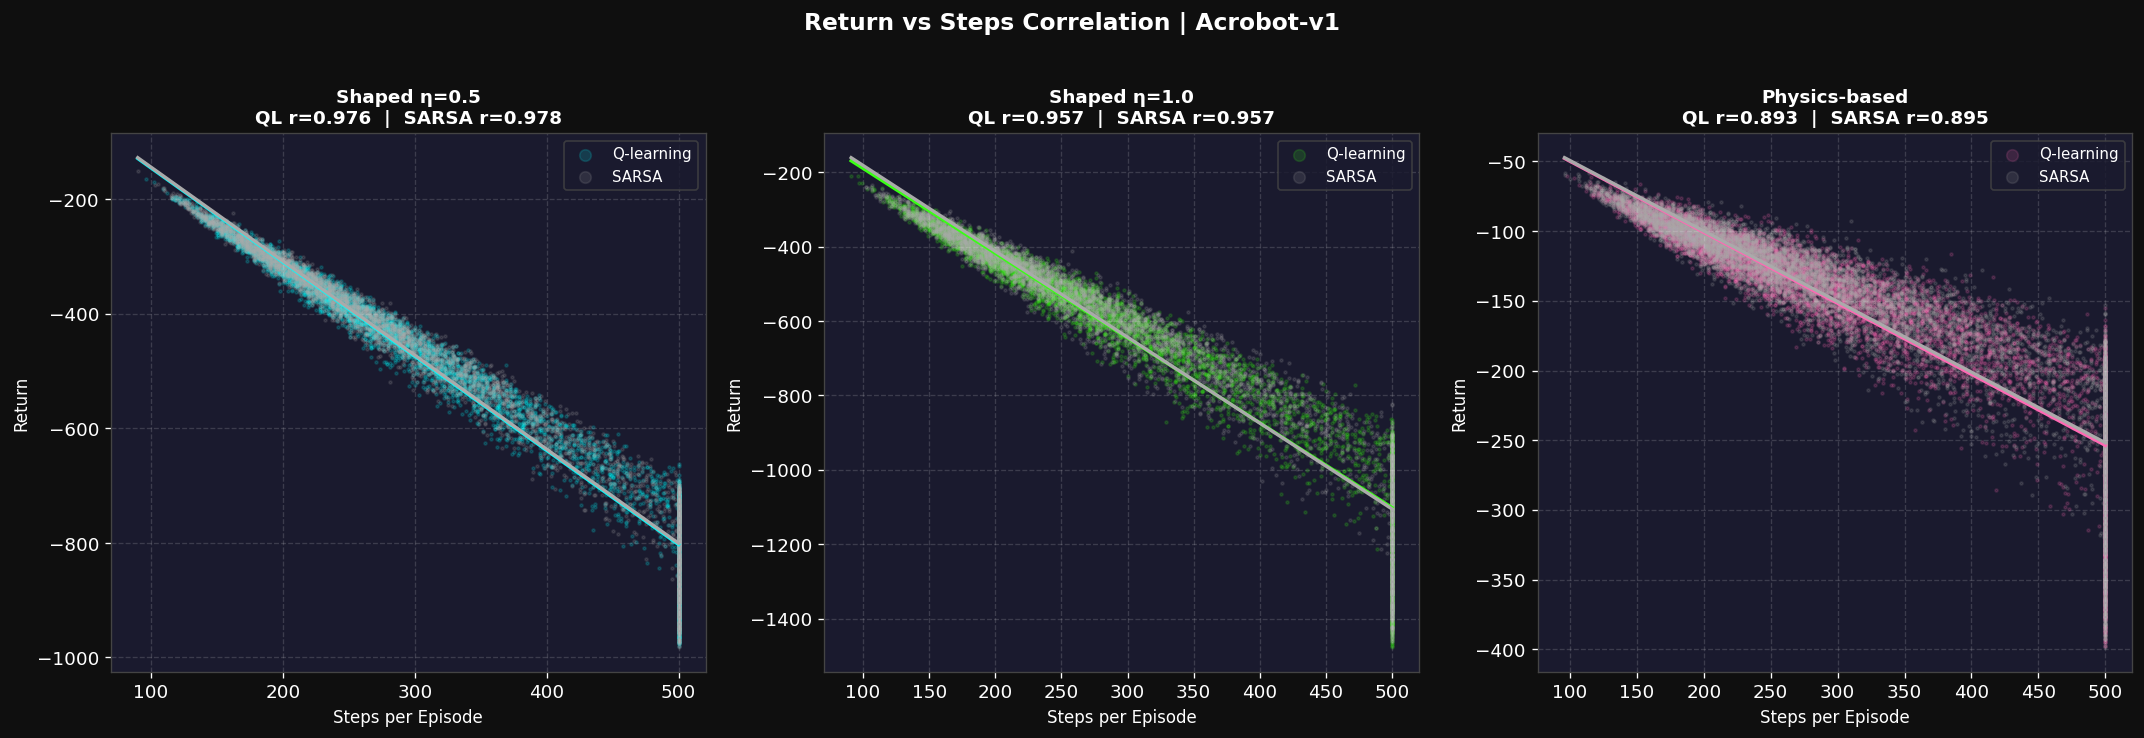

In [11]:
print(f'{"Reward Function":<28} {"Algorithm":<12} {"Corr (r)":>10} {"p-value":>12}')

for eta in ETAS:
    corr_ql,  p_ql  = correlation(ql_eta_rewards[eta],   ql_eta_steps[eta])
    corr_sar, p_sar = correlation(sarsa_eta_rewards[eta], sarsa_eta_steps[eta])
    print(f'{"Shaped η="+str(eta):<28} {"Q-learning":<12} {corr_ql:>10.3f} {p_ql:>12.2e}')
    print(f'{"":28} {"SARSA":<12} {corr_sar:>10.3f} {p_sar:>12.2e}')


corr_ql_upd,  p_ql_upd  = correlation(ql_upd_rewards,   ql_upd_steps)
corr_sar_upd, p_sar_upd = correlation(sarsa_upd_rewards, sarsa_upd_steps)
print(f'{"Physics-based":<28} {"Q-learning":<12} {corr_ql_upd:>10.3f} {p_ql_upd:>12.2e}')
print(f'{"":28} {"SARSA":<12} {corr_sar_upd:>10.3f} {p_sar_upd:>12.2e}')

eta_colors = {0.5: '#00FFFF', 1.0: '#39FF14'}

plot_configs = [
    ('Shaped η=0.5',  ql_eta_rewards[0.5], ql_eta_steps[0.5],
                      sarsa_eta_rewards[0.5], sarsa_eta_steps[0.5], eta_colors[0.5]),
    ('Shaped η=1.0',  ql_eta_rewards[1.0], ql_eta_steps[1.0],
                      sarsa_eta_rewards[1.0], sarsa_eta_steps[1.0], eta_colors[1.0]),
    ('Physics-based', ql_upd_rewards,      ql_upd_steps,
                      sarsa_upd_rewards,   sarsa_upd_steps,         '#FF69B4'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0f0f0f')

for ax, (title, ql_r, ql_s, sar_r, sar_s, color) in zip(axes, plot_configs):
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.grid(True, alpha=0.15, color='white', linestyle='--')

    ax.scatter(ql_s,  ql_r,  alpha=0.15, s=3, color=color,     label='Q-learning')
    ax.scatter(sar_s, sar_r, alpha=0.15, s=3, color='#AAAAAA', label='SARSA')

    xs = np.linspace(min(min(ql_s), min(sar_s)),
                     max(max(ql_s), max(sar_s)), 100)
    ax.plot(xs, np.polyval(np.polyfit(ql_s,  ql_r,  1), xs),
            color=color,     linewidth=2)
    ax.plot(xs, np.polyval(np.polyfit(sar_s, sar_r, 1), xs),
            color='#AAAAAA', linewidth=2)

    corr_ql,  _ = correlation(ql_r,  ql_s)
    corr_sar, _ = correlation(sar_r, sar_s)

    ax.set_title(f'{title}\nQL r={corr_ql:.3f}  |  SARSA r={corr_sar:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Steps per Episode', fontsize=10)
    ax.set_ylabel('Return',            fontsize=10)
    ax.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white',
              edgecolor='#444444', markerscale=4)

fig.suptitle('Return vs Steps Correlation | Acrobot-v1',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('correlation_scatter.png', bbox_inches='tight',
            dpi=150, facecolor='#0f0f0f')
plt.show()

#Arigato